# Data Contamination
Compare AR(1) cyclic-signal detection when the conditional flow noise model is trained with increasing contamination in the training set.

In [3]:
from pathlib import Path
import sys
import yaml
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import Config
from src.model.flow_matching_model.samples import Samples
from src.utils.cyclic_detector import CyclicDetector
from src.utils.drw import DRWManager
from src.utils.light_curve_sin_dataset import LightCurvesSinDataset
from src.utils.noise_models import AR1NoiseModel
from src.utils.rendering import plot_pvalue_histograms_from_items, plot_rocs_from_items
import src.model.flow_matching_model as flow_matching

NOTEBOOK_DIR = ROOT / 'figures' / 'paper' / 'data_contamination'
ROC_PATH = NOTEBOOK_DIR / 'data_contamination_roc.png'
PVALUE_PATH = NOTEBOOK_DIR / 'data_contamination_p_values.png'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 11

torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [4]:
def load_config(output_name: str) -> Config:
    with open(ROOT / 'outputs' / output_name / 'config.yaml', 'r') as handle:
        return Config(**yaml.safe_load(handle))


def load_flow_model(output_name: str, checkpoint_name: str):
    config = load_config(output_name)
    wrapper_cls = getattr(flow_matching, config.lightning_wrapper)
    checkpoint_path = ROOT / 'outputs' / output_name / checkpoint_name
    model = wrapper_cls.load_from_checkpoint(checkpoint_path, config=config, map_location=DEVICE)
    return model.eval().to(DEVICE)


class PaperFlowNoiseModel:
    def __init__(self, model, num_steps: int = 40):
        self.model = model
        self.num_steps = int(num_steps)

    @torch.no_grad()
    def generates_curves_like(self, reference_curves, parameters, num_curves):
        curves = torch.as_tensor(reference_curves, dtype=torch.float32, device=self.model.device)
        if curves.ndim == 2:
            curves = curves[:, None, :]
        domain_curves = self.model.to_domain(Samples(curves, domain='time', t=1)).curves
        condition = self.model.encode(domain_curves)
        condition = condition[:, None].repeat(1, num_curves, 1).flatten(0, 1)
        generated = self.model.domain_sample(condition.shape[0], condition=condition, num_steps=self.num_steps)
        time_curves = self.model.to_domain(generated, 'time').curves[:, 0]
        return time_curves.reshape(curves.shape[0], num_curves, -1).cpu()


In [ ]:
SIGMA = 0.2
DATASET_SIZE = 250
NUM_MC_CURVES = 100
BATCH_SIZE = 20
CONTAMINATION_RUNS = {
    '0%': 'gaussian prior - data contamination 0%',
    "0.5": 'gaussian prior - data contamination 0.1%',
    '1%': 'gaussian prior - data contamination 1%',
    '5%': 'gaussian prior - data contamination 5%',
    '10%': 'gaussian prior - data contamination 10%',
    '20%': 'gaussian prior - data contamination 20%',
}

seed_all(SEED)
manager = DRWManager(sigma=SIGMA, observation_noise=0.0)
dataset = LightCurvesSinDataset(
    AR1NoiseModel(manager),
    cycle_length_range=(30, 80),
    snr_rms_range=(0.8, 1.2),
    dataset_size=DATASET_SIZE,
    seed=SEED,
)

baseline_detector = CyclicDetector(
    dataset,
    AR1NoiseModel(manager),
    num_simulated_light_curves=NUM_MC_CURVES,
)
baseline_p_values, baseline_labels = baseline_detector.get_p_value_for_dataset(batch_size=BATCH_SIZE)

results = {
    'AR(1) Baseline': {
        'p_values': baseline_p_values.cpu(),
        'labels': baseline_labels.cpu(),
    }
}

for index, (label, output_name) in enumerate(CONTAMINATION_RUNS.items()):
    seed_all(SEED * 100 + index)
    # model = load_flow_model(output_name, 'step=step=025000.ckpt')
    model = load_flow_model(output_name, 'step=step=050000.ckpt')
    detector = CyclicDetector(
        dataset,
        PaperFlowNoiseModel(model, num_steps=40),
        num_simulated_light_curves=NUM_MC_CURVES,
    )
    p_values, labels = detector.get_p_value_for_dataset(batch_size=BATCH_SIZE)
    results[f'Flow ({label})'] = {
        'p_values': p_values.cpu(),
        'labels': labels.cpu(),
        'contamination': label,
    }

{key: float((1.0 - value['p_values'][value['labels']]).mean()) for key, value in results.items()}


 31%|███       | 4/13 [00:00<00:00, 32.99it/s]

100%|██████████| 13/13 [00:00<00:00, 33.78it/s]
/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.5.5, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(
  0%|          | 0/13 [00:00<?, ?it/s]

PosixPath('/nfs/scistore20/bronsgrp/nsellam/astro-diffusion/figures/paper/data_contamination/data_contamination_roc.png')

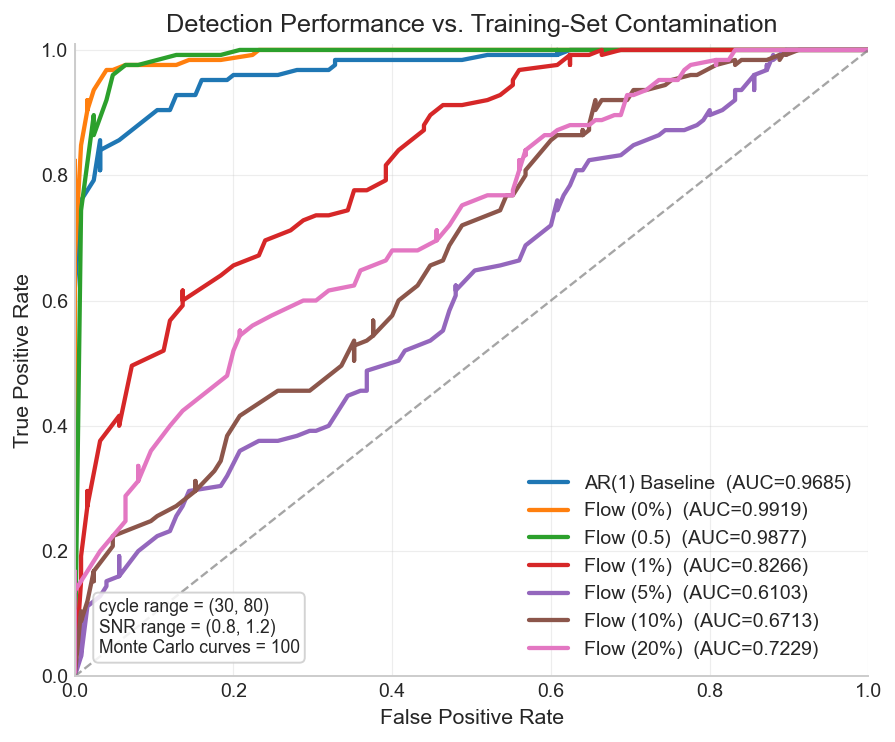

In [ ]:
roc_items = [
    (name, payload['p_values'], payload['labels'])
    for name, payload in results.items()
]

fig, ax = plt.subplots(figsize=(6.5, 5.4))
plot_rocs_from_items(
    roc_items,
    ax=ax,
    title='Detection Performance vs. Training-Set Contamination',
)
ax.text(
    0.03,
    0.03,
    f'cycle range = (30, 80)\nSNR range = (0.8, 1.2)\nMonte Carlo curves = {NUM_MC_CURVES}',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=9,
    bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.85, 'edgecolor': '0.8'},
)
ax.set_ylim(0,1.01)
fig.tight_layout()
fig.savefig(ROC_PATH, bbox_inches='tight')
ROC_PATH


In [ ]:
def plot_pvalue_histograms_grid_4col(
    items,
    bins: int = 40,
    density: bool = True,
    title="p-value distributions",
    alpha=0.55,
    ylim_max: float = None,
    fontsize: float = 12,
):
    """
    Creates a grid layout with 2 rows and 6 columns.
    
    Layout: Each row contains 3 cases, each taking up 2 columns (positive and negative).
    Row 1: Case0_Pos | Case0_Neg | Case1_Pos | Case1_Neg | Case2_Pos | Case2_Neg
    Row 2: Case3_Pos | Case3_Neg | Case4_Pos | Case4_Neg | Case5_Pos | Case5_Neg
    
    Parameters:
        items: list of (name, p_values, labels) tuples
        bins: number of histogram bins
        density: whether to normalize histograms
        title: figure title
        alpha: histogram alpha transparency
        ylim_max: optional fixed y-axis max
        fontsize: font size for all labels
    """
    
    # Parse inputs
    parsed = []
    for it in items:
        if isinstance(it, dict):
            p = it["p_values"]
            y = it["labels"]
            name = it.get("name", "case")
        elif isinstance(it, (list, tuple)) and len(it) == 2:
            p, y = it
            name = "case"
        elif isinstance(it, (list, tuple)) and len(it) == 3:
            name, p, y = it
        else:
            raise ValueError(
                "Each item must be dict with keys {p_values, labels} (optional name), "
                "or tuple (p, y) / (name, p, y)."
            )
        parsed.append((name, p, y))

    n_items = len(parsed)
    if n_items != 6:
        raise ValueError(f"Expected exactly 6 items, got {n_items}")

    # Colors
    blue = "cornflowerblue"
    red = "salmon"

    # Create 2x6 grid
    fig, axes = plt.subplots(
        2, 6,
        figsize=(16, 6),
        sharex=True,
        sharey=True,
    )

    # Flatten axes for easier indexing
    axes_flat = axes.flatten()

    # Plot each item: 6 items → 12 subplots (2 per item: positive, negative)
    for item_idx, (name, p, y) in enumerate(parsed):
        
        # Convert tensors
        p_t = _as_cpu_flat_float64(p)
        y_t = _as_cpu_flat_bool(y)

        p_pos = p_t[y_t].numpy()
        p_neg = p_t[~y_t].numpy()

        # Two consecutive axes: [pos, neg]
        ax_pos = axes_flat[2 * item_idx]
        ax_neg = axes_flat[2 * item_idx + 1]

        # Style axes
        for ax in (ax_pos, ax_neg):
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
            ax.set_axisbelow(True)
            ax.set_xlim(0, 1)
            if ylim_max is not None:
                ax.set_ylim(0, ylim_max)
            ax.tick_params(axis="both", labelsize=fontsize - 2)

        # Positive histogram (blue)
        ax_pos.hist(
            p_pos,
            bins=bins,
            range=(0, 1),
            density=density,
            histtype="stepfilled",
            linewidth=1.4,
            alpha=alpha,
            color=blue,
            edgecolor="white",
        )

        # Negative histogram (red)
        ax_neg.hist(
            p_neg,
            bins=bins,
            range=(0, 1),
            density=density,
            histtype="stepfilled",
            linewidth=1.4,
            alpha=alpha,
            color=red,
            edgecolor="white",
        )

        # Titles
        ax_pos.set_title(f"{name} | Positive", fontsize=fontsize - 1)
        ax_neg.set_title(f"{name} | Negative", fontsize=fontsize - 1)

        # Y-label only on leftmost axes
        if item_idx % 3 == 0:
            ax_pos.set_ylabel("Density" if density else "Count", fontsize=fontsize)

    # X-labels on bottom row
    for ax in axes_flat[-6:]:
        ax.set_xlabel("p-value", fontsize=fontsize)

    if title:
        fig.suptitle(title, y=0.995, fontsize=fontsize)

    fig.tight_layout()
    return fig, axes

In [ ]:
labels_in_order = list(CONTAMINATION_RUNS)
histogram_items = [
    ('AR(1) Baseline', results['AR(1) Baseline']['p_values'], results['AR(1) Baseline']['labels']),
    (f'Flow (0%)', results[f'Flow (0%)']['p_values'], results[f'Flow (0%)']['labels']),
    (f'Flow (0.5%)', results[f'Flow (0.5%)']['p_values'], results[f'Flow (0.5%)']['labels']),
    (f'Flow (1%)', results[f'Flow (1%)']['p_values'], results[f'Flow (1%)']['labels']),
    (f'Flow (5%)', results[f'Flow (5%)']['p_values'], results[f'Flow (5%)']['labels']),
    (f'Flow (10%)', results[f'Flow (10%)']['p_values'], results[f'Flow (10%)']['labels']),
]

fig, _ = plot_pvalue_histograms_grid_4col(
    histogram_items,
    bins=40,
    density=True,
    title=None,
    fontsize=20,
)
fig.savefig(PVALUE_PATH, bbox_inches='tight', dpi=150)

NameError: name 'CONTAMINATION_RUNS' is not defined

In [ ]:
for name, payload in results.items():
    positives = payload['p_values'][payload['labels']]
    negatives = payload['p_values'][~payload['labels']]
    print(
        f"{name:>15} | positive mean p = {positives.mean():.4f} | negative mean p = {negatives.mean():.4f}"
    )


 AR(1) Baseline | positive mean p = 0.0520 | negative mean p = 0.4829
      Flow (0%) | positive mean p = 0.0210 | negative mean p = 0.3936
     Flow (0.5) | positive mean p = 0.0172 | negative mean p = 0.3758
      Flow (1%) | positive mean p = 0.1363 | negative mean p = 0.3852
      Flow (5%) | positive mean p = 0.3244 | negative mean p = 0.4199
     Flow (10%) | positive mean p = 0.2554 | negative mean p = 0.4024
     Flow (20%) | positive mean p = 0.2222 | negative mean p = 0.4055
